# Segmentación de la banda de goma — EfficientSAM

**Entrada:** `../outputs/detections/rubber_detections.json`
(generado por `rubber_detection.ipynb`, sección 6)

**Pipeline:**
1. Carga las bboxes de rubber_strip ya detectadas por YOLO
2. Para cada bbox, EfficientSAM genera la máscara pixel a pixel
3. Visualización y guardado en `../outputs/figures/rubber_segmentation/`

In [12]:
import json
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# --- Rutas ---
DETECTIONS_JSON = Path("../outputs/detections/rubber_detections.json")
RAW_DIR         = Path("../data/raw")
ESAM_WEIGHTS    = Path("efficient_sam_vitt.pt")

assert DETECTIONS_JSON.exists(), (
    f"No se encontró {DETECTIONS_JSON.resolve()}\n"
    "Ejecuta primero la sección 6 de rubber_detection.ipynb"
)
assert ESAM_WEIGHTS.exists(), f"Pesos no encontrados: {ESAM_WEIGHTS.resolve()}"

# --- EfficientSAM (ViT-Tiny) ---
from efficient_sam.efficient_sam import build_efficient_sam

sam = build_efficient_sam(
    encoder_patch_embed_dim=192,
    encoder_num_heads=3,
    checkpoint=str(ESAM_WEIGHTS),
)
sam.eval()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
sam = sam.to(DEVICE)

# --- Detecciones ---
detections = json.loads(DETECTIONS_JSON.read_text())

COLOR_BBOX = (255, 220,   0)   # amarillo — bbox YOLO
COLOR_MASK = (255,  80,   0)   # naranja   — máscara SAM
ALPHA      = 0.50

print(f"EfficientSAM listo en {DEVICE}")
print(f"Imágenes con detecciones: {len(detections)}")
print(f"Total bboxes: {sum(len(v) for v in detections.values())}")

EfficientSAM listo en cuda
Imágenes con detecciones: 22
Total bboxes: 45


## 2. Función de segmentación

In [13]:
def run_efficient_sam(image_np, box_xyxy):
    """
    Segmenta la región delimitada por box_xyxy.
    Usa las esquinas TL y BR como prompt (labels 2 y 3).
    Devuelve una máscara booleana del tamaño original de la imagen.
    """
    H, W = image_np.shape[:2]
    x1, y1, x2, y2 = [int(v) for v in box_xyxy]

    pad  = 15
    x1p  = max(0, x1 - pad);  y1p = max(0, y1 - pad)
    x2p  = min(W, x2 + pad);  y2p = min(H, y2 + pad)
    crop = image_np[y1p:y2p, x1p:x2p]

    bx1 = float(x1 - x1p);  by1 = float(y1 - y1p)
    bx2 = float(x2 - x1p);  by2 = float(y2 - y1p)

    img_t = torch.from_numpy(crop).permute(2, 0, 1).float() / 255.0
    img_t = img_t.unsqueeze(0).to(DEVICE)

    pts = torch.tensor([[[[bx1, by1], [bx2, by2]]]], dtype=torch.float32).to(DEVICE)
    lbl = torch.tensor([[[2, 3]]],                   dtype=torch.int32).to(DEVICE)

    with torch.no_grad():
        masks, scores = sam(img_t, pts, lbl)

    best      = scores[0, 0].argmax().item()
    crop_mask = masks[0, 0, best].cpu().numpy() > 0.5

    full_mask = np.zeros((H, W), dtype=bool)
    full_mask[y1p:y2p, x1p:x2p] = crop_mask
    return full_mask


print("run_efficient_sam lista.")

run_efficient_sam lista.


## 3. Test sobre una imagen

multimedia_01.jpg  —  2 bbox(es) detectada(s)


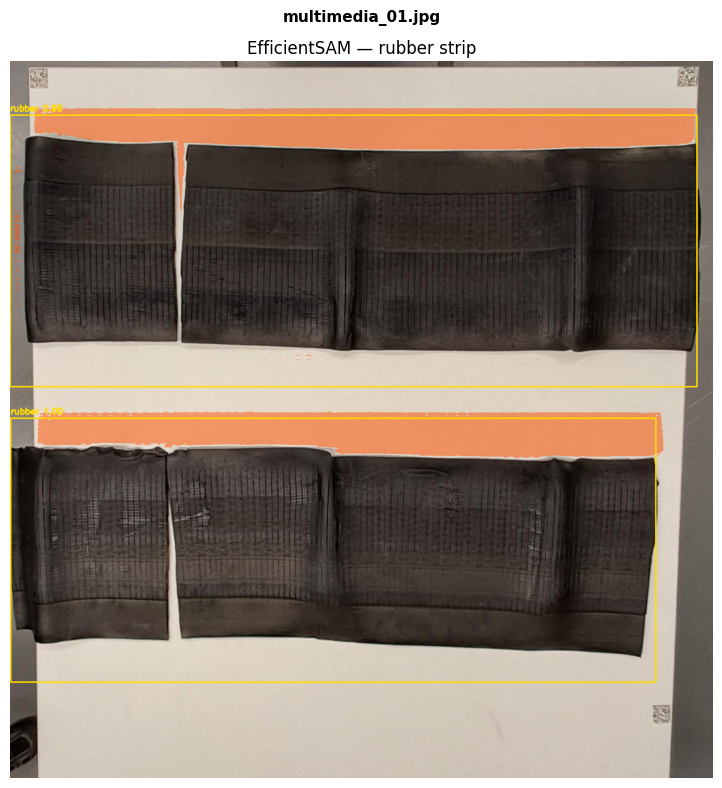

In [14]:
TARGET = "multimedia_01.jpg"   # cambia aquí para probar otra imagen

img_path = RAW_DIR / TARGET
img_bgr  = cv2.imread(str(img_path))
img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

bboxes = detections.get(TARGET, [])
print(f"{TARGET}  —  {len(bboxes)} bbox(es) detectada(s)")

overlay = img_rgb.copy().astype(np.float32)

for det in bboxes:
    x1, y1, x2, y2 = det["bbox"]
    conf = det["conf"]

    mask = run_efficient_sam(img_rgb, [x1, y1, x2, y2])

    colored = np.zeros_like(overlay)
    colored[mask] = COLOR_MASK
    overlay = np.where(mask[:, :, None], overlay * (1 - ALPHA) + colored * ALPHA, overlay)

    ov_u8 = overlay.astype(np.uint8)
    cv2.rectangle(ov_u8, (x1, y1), (x2, y2), COLOR_BBOX, 2)
    cv2.putText(ov_u8, f"rubber {conf:.2f}",
                (x1, max(y1 - 8, 14)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, COLOR_BBOX, 2)
    overlay = ov_u8.astype(np.float32)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(overlay.astype(np.uint8))
ax.set_title("EfficientSAM — rubber strip")
ax.axis("off")
plt.suptitle(TARGET, fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Segmentar todo el dataset y guardar

In [15]:
OUT_DIR = Path("../outputs/figures/rubber_segmentation")
OUT_DIR.mkdir(parents=True, exist_ok=True)

for img_name, bboxes in sorted(detections.items()):
    img_path = RAW_DIR / img_name
    if not img_path.exists():
        print(f"  [SKIP] {img_name}: imagen no encontrada")
        continue

    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    overlay = img_rgb.copy().astype(np.float32)

    for det in bboxes:
        x1, y1, x2, y2 = det["bbox"]
        conf = det["conf"]
        try:
            mask = run_efficient_sam(img_rgb, [x1, y1, x2, y2])

            colored = np.zeros_like(overlay)
            colored[mask] = COLOR_MASK
            overlay = np.where(mask[:, :, None], overlay * (1 - ALPHA) + colored * ALPHA, overlay)

            ov_u8 = overlay.astype(np.uint8)
            cv2.rectangle(ov_u8, (x1, y1), (x2, y2), COLOR_BBOX, 2)
            cv2.putText(ov_u8, f"{conf:.2f}",
                        (x1, max(y1 - 8, 14)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, COLOR_BBOX, 2)
            overlay = ov_u8.astype(np.float32)
        except Exception as e:
            print(f"  [WARN] {img_name} bbox={det['bbox']}: {e}")

    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(overlay.astype(np.uint8))
    ax.set_title("EfficientSAM — rubber strip")
    ax.axis("off")
    fig.text(0.5, 0.01, f"{len(bboxes)} rubber strip(s) segmentado(s)", ha="center", fontsize=8, color="#444")
    fig.suptitle(img_name, fontsize=11, fontweight="bold")
    plt.tight_layout(rect=[0, 0.03, 1, 1])

    plt.savefig(OUT_DIR / (Path(img_name).stem + ".jpg"), dpi=100, bbox_inches="tight")
    plt.close()
    print(f"  {img_name} → {len(bboxes)} mask(s) guardadas")

print(f"\nFiguras guardadas en: {OUT_DIR.resolve()}")

  multimedia_01.jpg → 2 mask(s) guardadas
  multimedia_02.jpg → 2 mask(s) guardadas
  multimedia_03.jpg → 2 mask(s) guardadas
  multimedia_04.jpg → 2 mask(s) guardadas
  multimedia_05.jpg → 2 mask(s) guardadas
  multimedia_06.jpg → 2 mask(s) guardadas
  multimedia_07.jpg → 3 mask(s) guardadas
  multimedia_08.jpg → 2 mask(s) guardadas
  multimedia_09.jpg → 2 mask(s) guardadas
  multimedia_10.jpg → 2 mask(s) guardadas
  multimedia_11.jpg → 2 mask(s) guardadas
  multimedia_12.jpg → 2 mask(s) guardadas
  multimedia_13.jpg → 2 mask(s) guardadas
  multimedia_14.jpg → 2 mask(s) guardadas
  multimedia_15.jpg → 2 mask(s) guardadas
  multimedia_16.jpg → 2 mask(s) guardadas
  multimedia_17.jpg → 2 mask(s) guardadas
  multimedia_18.jpg → 2 mask(s) guardadas
  multimedia_19.jpg → 2 mask(s) guardadas
  multimedia_20.jpg → 2 mask(s) guardadas
  multimedia_21.jpg → 2 mask(s) guardadas
  multimedia_22.jpg → 2 mask(s) guardadas

Figuras guardadas en: C:\Users\jaime\Proyectos\VA_RetoMichelin\models\Jaime

In [ ]:
image_paths = sorted(glob.glob(os.path.join(DATASET_PATH, "*.jpg")))
print(f"Imágenes: {len(image_paths)}")

results = []
for path in image_paths:
    fname = os.path.basename(path)
    try:
        _, qrs_i = detect_qrs(path, show=False)
        if len(qrs_i) < 2:
            print(f"  [SKIP] {fname}: solo {len(qrs_i)} QRs")
            results.append((fname, False, None))
            continue
        warped_i, _, _ = warp_workspace(path, qrs_i, output_size=(1000, 1400), show=False)
        mask_i, cnt_i, bbox_i = segment_rubber_band(warped_i, show=False)
        ok = cnt_i is not None
        tag = 'OK  ' if ok else 'FAIL'
        area = int(cv2.contourArea(cnt_i)) if ok else 0
        print(f"  [{tag}] {fname}: área={area} px²  bbox={bbox_i}")
        results.append((fname, ok, bbox_i))
    except Exception as e:
        print(f"  [ERR ] {fname}: {e}")
        results.append((fname, False, None))

n_ok = sum(1 for _, ok, _ in results if ok)
print(f"\nSegmentación exitosa: {n_ok}/{len(image_paths)} ({100*n_ok/max(len(image_paths),1):.1f}%)")